## Transformer Encoder for Rainfall-Runoff Modeling

### A) Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.nn.modules.linear import NonDynamicallyQuantizableLinear
import torch.nn.functional as F
import math
import scipy.io
import torch.utils.data as data_utils
import pandas as pd
import time, datetime
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
torch.cuda.empty_cache()
import warnings
warnings.filterwarnings(action='ignore')
from torch.utils.data import DataLoader, TensorDataset
from scipy.io import savemat

 
#--------------------------------#
#           A) Model             #
#--------------------------------#
    
def get_position_encoding(seq_len, d_model):
    """
       Compute the Positional Encoding matrix:
         PE(pos,2i)   = sin(pos/(10000^(2i/d_model)))
         PE(pos,2i+1) = cos(pos/(10000^(2i/d_model)))

    """
    dim=60
    mod = (365*2/(2*np.pi))**(15/2)
    pos_enc = np.zeros((seq_len, d_model))
    for k in range(seq_len):
        ii=4
        denominator = np.power(mod, 2*ii/dim)
        pos_enc[k, 0:d_model] = np.cos(k/denominator)

    return torch.FloatTensor(pos_enc)

#####################################################################

class customEncoderLayer(nn.Module):

    def __init__(self, d_model, nhead, dim_feedforward, dropout, device, batch_first, activation = F.relu, layer_norm_eps: float = 1e-5):

        super().__init__()
        self.multihead_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=batch_first, device=device)

        # Implementation of Feedforward model
        self.linear1 = nn.Linear(d_model, dim_feedforward, device=device)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model, device=device)
        self.norm1 = nn.LayerNorm(d_model, eps=layer_norm_eps, device=device)
        self.norm2 = nn.LayerNorm(d_model, eps=layer_norm_eps, device=device)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        if activation is F.relu or isinstance(activation, torch.nn.ReLU):
            self.activation_relu_or_gelu = 1

        elif activation is F.gelu or isinstance(activation, torch.nn.GELU):
            self.activation_relu_or_gelu = 2

        else:
            self.activation_relu_or_gelu = 0
            self.activation = activation

    def __setstate__(self, state):
        super().__setstate__(state)
        if not hasattr(self, 'activation'):
            self.activation = F.relu


    def forward(self, src, memory_mask = None, memory_key_padding_mask = None, is_causal = False):

        # memory_is_causal does not have an effect
        x = src
        tmp, att_weight = self._mha_block(x[:,[-1],:], x, memory_mask, is_causal)
        x = self.norm1(x + tmp)
        x = self.norm2(x + self._ff_block(x))

        if self.training:
            return x
        else:
            return x, att_weight


    # multihead attention block
    def _mha_block(self, x, mem, attn_mask, key_padding_mask,is_causal: bool = False):
        x, att_weights = self.multihead_attn(x, mem, mem, attn_mask=attn_mask, is_causal=is_causal)
        return self.dropout2(x), att_weights


    # feed forward block
    def _ff_block(self, x):
        x = self.linear2(self.dropout(F.relu(self.linear1(x))))
        return self.dropout2(x)



####################################################

class TimeSeriesTransformer(nn.Module):

    def __init__(self, d_input, d_embed, nhead, num_encoder_layers, d_feedforward, d_output, dropout, device):

        super(TimeSeriesTransformer, self).__init__()

        self.model_type = 'Transformer'
        self.input_embedding = nn.Linear(d_input, d_embed,device=device)
        self.src_mask = None
        self.tgt_mask = None
        self.memory_mask = None
        self.pos_encoder = get_position_encoding(365, d_embed).to(device)
        self.encoder_layer = customEncoderLayer(d_model=d_embed,nhead=nhead, dim_feedforward=d_feedforward, dropout=dropout,batch_first=True, device=device)
        #self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer,
        # num_layers=num_encoder_layers)
        self.device = device
        self.decoder = nn.Linear(d_embed,d_output,device=device)
        self.init_weights()

    def init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self,x):
        src = self.input_embedding(x)
        src = self.pos_encoder*0.2 + src

        if self.training:
            output = self.encoder_layer(src)
            output = output[:,-1,:]
            output = self.decoder(output)

        else:
            output, att_weight = self.encoder_layer(src)
            output = output[:,-1,:]
            output = self.decoder(output)       

        if self.training:
            return output[:,-1]

        else:
            return output[:,-1], att_weight


    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))

        return mask

def minmaxnorm(dat):
    dat[:,:,0] = np.log(np.sqrt(dat[:,:,0]) + 0.1)
    y, x1, x2 = dat[:,:,0], dat[:,:,1], dat[:,:,2]
    ymin = np.nanmin(y[:,-1])
    y=y-ymin
    ymax=np.nanmax(y[:,-1])
    y=y/ymax
    dat[:,:,0] = y
    return dat

# hyperparameters
cfg = {
    'seq_len': 365,   
    'batch_size': 256,  
    'd_input' : 2,
    'numEpoch' : 10,
    'dim_output' : 1,
    'nlayers' : 1,
    'd_embed' : 8,
    'num_heads' : 2,  
    'learning_rate' : .005,   
    'dropout' : 0.05,
    'dim_feedforward' : 128
    }
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('The model will run on', device)    

The model will run on cuda


### B) Load data

In [9]:
dat_original  = scipy.io.loadmat('dataset/data.mat')['data'] # Replace the name of data
dat = minmaxnorm(dat_original)

# train:validation:test
train_size 
vald_size 
test_size 
dataX = torch.Tensor(np.stack((x1, x2), axis=-1)) 
dataY = torch.Tensor( y )
X_train = dataX[0:train_size+vald_size,0:-1,:]
y_train = dataY[0:train_size+vald_size,-1]
X_val = dataX[train_size:train_size+vald_size,0:-1,:]
y_val = dataY[train_size:train_size+vald_size,-1]
X_test = dataX[train_size+vald_size:num,0:-1,:]
y_test = dataY[train_size+vald_size:num,-1]

# Batch
train_data = data_utils.TensorDataset( X_train, y_train)
train_loader = data_utils.DataLoader(train_data, batch_size = cfg['batch_size'], shuffle = True, drop_last=False)
vald_data = data_utils.TensorDataset( X_val, y_val)
vald_loader = data_utils.DataLoader(vald_data, batch_size = cfg['batch_size'], shuffle = False, drop_last=False)
test_data = data_utils.TensorDataset( X_test, y_test)
test_loader = data_utils.DataLoader(test_data, batch_size = cfg['batch_size'], shuffle = False, drop_last=False)

### C) Training

In [12]:
torch.manual_seed(1234)
best_model_params_path = '/transformer_RR.pth'
myModel = TimeSeriesTransformer(cfg['d_input'], cfg['d_embed'], cfg['num_heads'], cfg['nlayers'], cfg['dim_feedforward'], cfg['dim_output'], cfg['dropout'], device) 
myModel.to(device)
criterion = torch.nn.MSELoss()  
optimizer = torch.optim.Adam(myModel.parameters(), lr=cfg['learning_rate'], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

############################################
#              training!                   #
############################################
t0 = time.time()
df_train = pd.DataFrame(columns=('epoch', 'loss_train', 'loss_vald', 'loss_test'))

for epoch in range(cfg['numEpoch']):

    # a new epoch begins
    running_loss = []

    # C.1) training set
    myModel.train()        
    for batch_num, (X_train, Y_train) in enumerate(train_loader):
        # loss
        optimizer.zero_grad()
        score = myModel(X_train[:,0:365,:].to(device))
        loss = criterion(score, Y_train.to(device)) 
        loss.backward()
        optimizer.step()
        running_loss.append(loss.item())

    # C.2) validation set
    myModel.eval()         
    vald_loss = []
    test_loss = []
    with torch.no_grad():
        for batch_idx, (X_vald, Y_vald) in enumerate(vald_loader):
            score, att_var = myModel(X_vald[:,0:365,:].to(device)) 
            loss = criterion(score, Y_vald.to(device)) 
            vald_loss.append(loss.item())

        for batch_idx, (X_test, Y_test) in enumerate(test_loader):
            score, att_var = myModel(X_test[:,0:365,:].to(device)) 
            loss = criterion(score, Y_test.to(device)) 
            test_loss.append(loss.item())

    # C.3) statistics for this epoch
    # normalize
    epoch_train_loss = np.nanmean(running_loss)
    epoch_vald_loss = np.nanmean(vald_loss)
    epoch_test_loss = np.nanmean(test_loss)

    #scheduler.step()
    if epoch != 0:
        if epoch % 10 == 0:
            scheduler.step()

    df_train.loc[epoch] = [epoch, epoch_train_loss, epoch_vald_loss, epoch_test_loss]

for p in myModel.parameters():
    if p.requires_grad:
        print(p.shape)                   

torch.Size([8, 2])
torch.Size([8])
torch.Size([24, 8])
torch.Size([24])
torch.Size([8, 8])
torch.Size([8])
torch.Size([128, 8])
torch.Size([128])
torch.Size([8, 128])
torch.Size([8])
torch.Size([8])
torch.Size([8])
torch.Size([8])
torch.Size([8])
torch.Size([1, 8])
torch.Size([1])


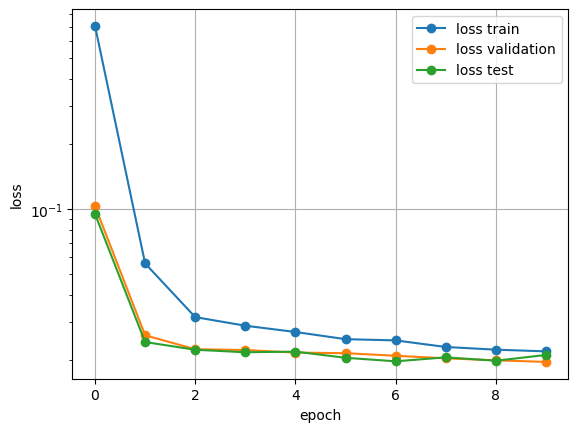

In [14]:
# loss plot
plt.figure(1);plt.clf()
plt.plot(df_train['epoch'],df_train['loss_train'],'-o',label='loss train')  
plt.plot(df_train['epoch'],df_train['loss_vald'],'-o',label='loss validation')
plt.plot(df_train['epoch'],df_train['loss_test'],'-o',label='loss test')
plt.yscale('log')
plt.xlabel(r'epoch')
plt.ylabel(r'loss')
plt.legend()
plt.grid(axis='both')